In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud
import re
# Better visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [6]:
df = pd.read_csv("../Data/Raw/Twitter_Sentiment_Dataset.csv", encoding='latin-1')

df.head()
df.shape

(1599999, 6)

In [7]:
df.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [8]:
df.columns = ["target", "id", "date", "flag", "user", "text"]

Change the Target Values

In [9]:
df["label"] = df["target"].apply(lambda x: 1 if x == 4 else 0)

Drop Useless Columns

In [10]:
df = df[["text", "label"]]

PRINT SHAPE


In [11]:

df.info()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1599999 entries, 0 to 1599998
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   text    1599999 non-null  str  
 1   label   1599999 non-null  int64
dtypes: int64(1), str(1)
memory usage: 24.4 MB


text     0
label    0
dtype: int64

Target Distribution Visualization

C:\Users\Kanchan Potdar\AppData\Local\Temp\ipykernel_18824\1286983435.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="label", data=df, palette=["#ff6b6b", "#4ecdc4"])


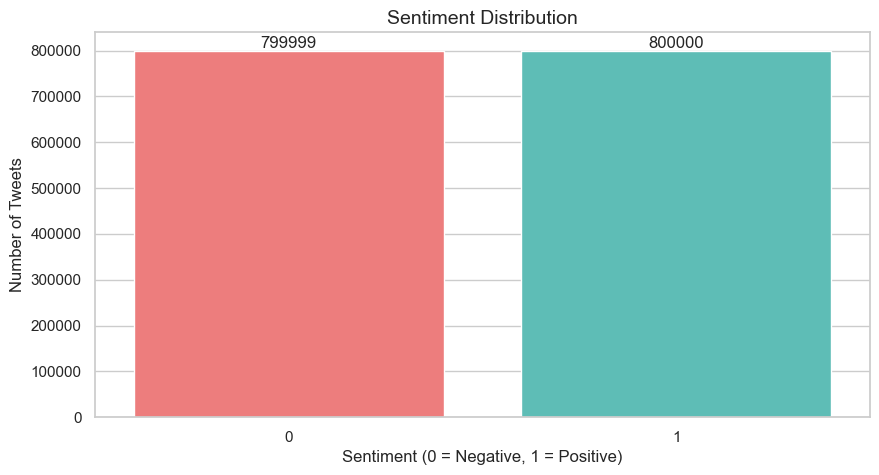

In [12]:
plt.figure()

ax = sns.countplot(x="label", data=df, palette=["#ff6b6b", "#4ecdc4"])

# Add labels on bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Number of Tweets")

plt.show()

 Text Length Analysis

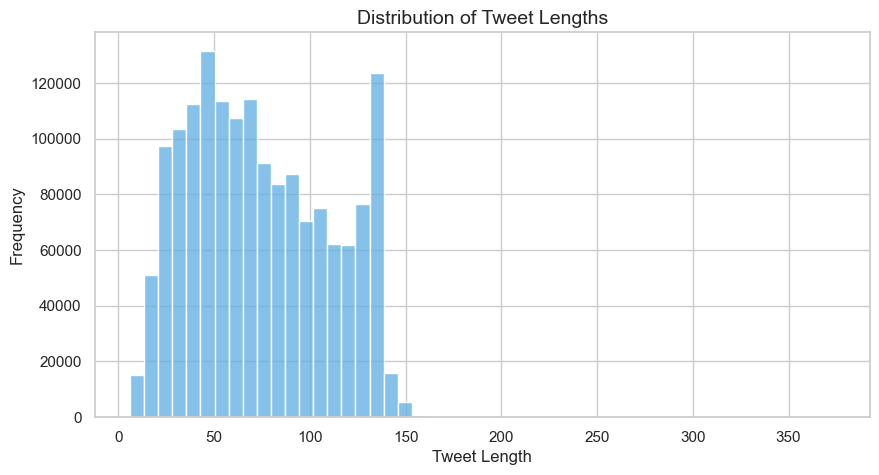

In [13]:
df["text_length"] = df["text"].apply(len)

plt.figure()

sns.histplot(df["text_length"], bins=50, color="#5dade2")

plt.title("Distribution of Tweet Lengths")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")

plt.show()

Compare by Sentiment

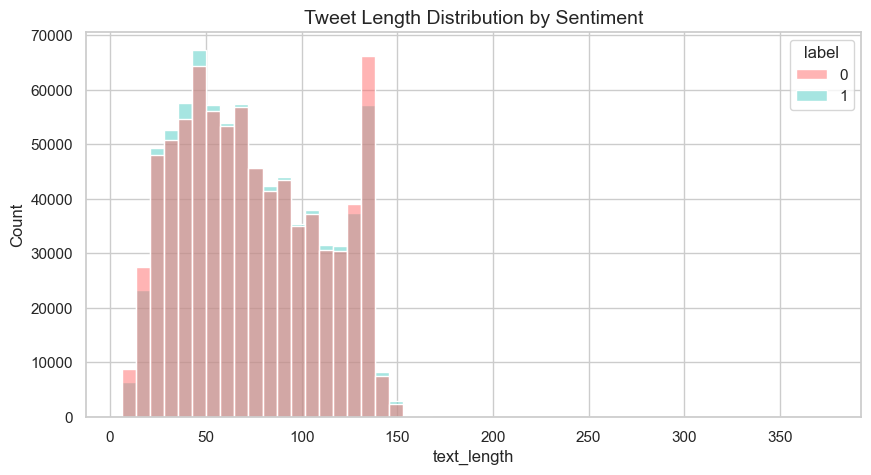

In [16]:
plt.figure()

sns.histplot(data=df, x="text_length", hue="label",
             bins=50, palette=["#ff6b6b", "#4ecdc4"])

plt.title("Tweet Length Distribution by Sentiment")

plt.show()

6. Text Cleaning (Light)

In [17]:
def simple_clean(text):
    text = text.lower()
    text = re.sub(r'http\S+|@\w+|#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df["clean_text"] = df["text"].apply(simple_clean)

Most Frequent Words (Better Visualization)

C:\Users\Kanchan Potdar\AppData\Local\Temp\ipykernel_18824\2348353735.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette="viridis")


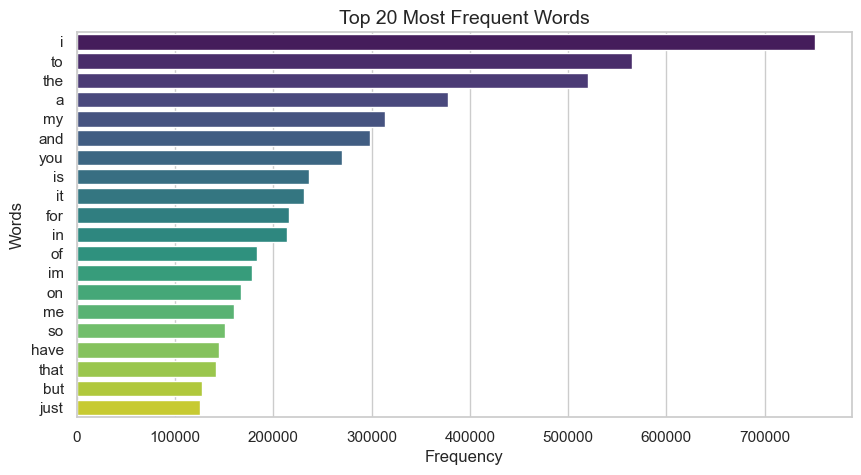

In [18]:
all_words = " ".join(df["clean_text"]).split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure()

sns.barplot(x=counts, y=words, palette="viridis")

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

Word Clouds (Styled)

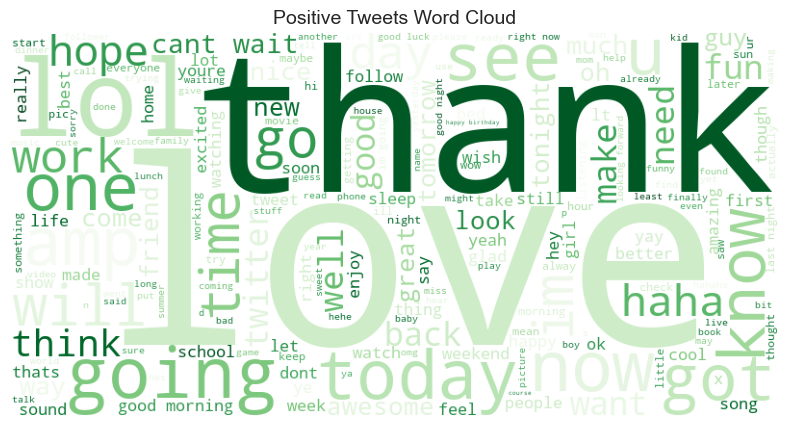

In [19]:
positive_text = " ".join(df[df["label"] == 1]["clean_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens'
).generate(positive_text)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Tweets Word Cloud")

plt.show()

Negative Tweets

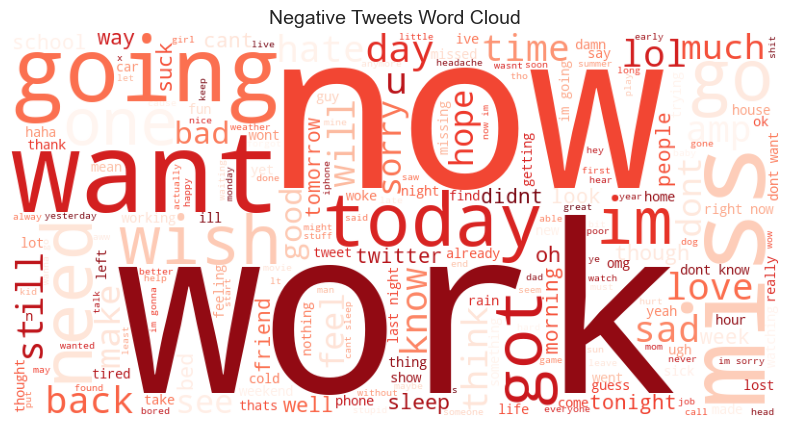

In [20]:
negative_text = " ".join(df[df["label"] == 0]["clean_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds'
).generate(negative_text)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Tweets Word Cloud")

plt.show()

Top words by sentiment

In [21]:
pos_words = " ".join(df[df["label"] == 1]["clean_text"]).split()
neg_words = " ".join(df[df["label"] == 0]["clean_text"]).split()

pos_common = Counter(pos_words).most_common(10)
neg_common = Counter(neg_words).most_common(10)

print("Top Positive Words:", pos_common)
print("Top Negative Words:", neg_common)

Top Positive Words: [('i', 288934), ('the', 263868), ('to', 251962), ('a', 197066), ('you', 176065), ('and', 147273), ('my', 125003), ('for', 117026), ('it', 111915), ('is', 108413)]
Top Negative Words: [('i', 462367), ('to', 312628), ('the', 256227), ('my', 189116), ('a', 180934), ('and', 151193), ('is', 127618), ('it', 119012), ('in', 114412), ('im', 103129)]


### Key Observations

- The dataset is balanced, so no resampling is required.
- Tweets are short and simple, making them suitable for classical ML models.
- Certain words strongly indicate sentiment (e.g., "love", "bad").
- Word frequency plays a major role in classification performance.
- Semantic relationships are less important than word importance.

### Connection to Model Results

- TF-IDF performs better because it captures word importance.
- Word2Vec underperforms due to loss of intensity when averaging embeddings.
- Linear models (Logistic Regression, SVM) perform best on this dataset.